# Classical ML Baseline: Boning vs Slicing

Window-based statistical features extracted from skeleton joint time-series data.

In [17]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from data.preprocessing import FEATURE_COLS

DATA_DIR = PROJECT_ROOT / "output_data"
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [18]:
def load_df(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

df_boning = load_df("P1_boning")
df_slicing = load_df("P1_slicing")

df2_boning = load_df("P2_boning")
df2_slicing = load_df("P2_slicing")

print(df_boning.shape, df_slicing.shape, df2_boning.shape, df2_slicing.shape)

(282794, 76) (251054, 76) (275464, 76) (251274, 76)


In [19]:
df_train = pd.concat([df_boning, df_slicing], ignore_index=True)
df_test = pd.concat([df2_boning, df2_slicing], ignore_index=True)

required_cols = set(FEATURE_COLS + ["activity_type", "Frame", "video_id"])
missing_train = required_cols - set(df_train.columns)
missing_test = required_cols - set(df_test.columns)

if missing_train:
    raise ValueError(f"Training data missing columns: {sorted(missing_train)}")
if missing_test:
    raise ValueError(f"Test data missing columns: {sorted(missing_test)}")

print("activity_type values:", sorted(df_train["activity_type"].unique()))

activity_type values: ['boning', 'slicing']


In [20]:
X = df_train[FEATURE_COLS]
y = df_train["activity_type"].astype(str)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_val.shape)

(427078, 69) (106770, 69)


In [21]:
constant_cols = [c for c in X_train.columns if X_train[c].nunique(dropna=False) <= 1]
X_train_var = X_train.drop(columns=constant_cols)
X_val_var = X_val.drop(columns=constant_cols)

variance_threshold = 0.01
vt = VarianceThreshold(threshold=variance_threshold)
X_train_var2 = vt.fit_transform(X_train_var)
kept_after_vt = X_train_var.columns[vt.get_support()]

X_train_var2 = pd.DataFrame(X_train_var2, columns=kept_after_vt, index=X_train_var.index)
X_val_var2 = pd.DataFrame(vt.transform(X_val_var), columns=kept_after_vt, index=X_val_var.index)

print(f"Removed constant columns: {len(constant_cols)}")
print(f"Kept after variance threshold: {len(kept_after_vt)}")

Removed constant columns: 3
Kept after variance threshold: 66


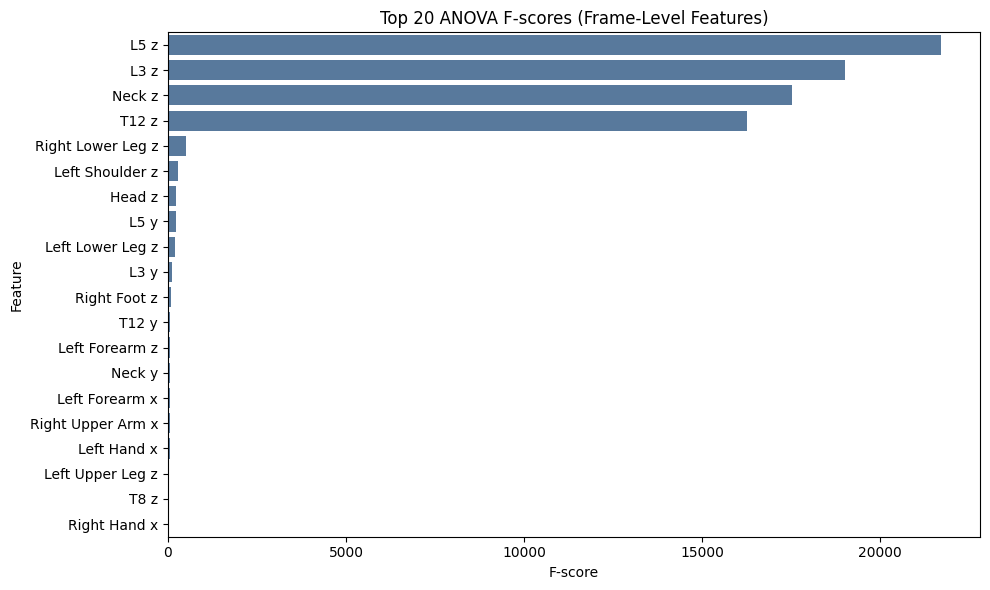

In [22]:
# ANOVA F-test on frame-level features (before windowing)
f_scores, p_values = f_classif(X_train_var2, y_train)
anova_df = pd.DataFrame({"feature": X_train_var2.columns, "f_score": f_scores, "p_value": p_values})
anova_df = anova_df.sort_values("f_score", ascending=False)
top_n = 20  # set to 10-20 as desired
top_anova = anova_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_anova, x="f_score", y="feature", color="#4C78A8")
plt.title(f"Top {top_n} ANOVA F-scores (Frame-Level Features)")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [23]:
def prepare_for_windowing(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    keep = ["video_id", "Frame", "activity_type"] + feature_cols
    return df[keep].copy()

train_df_sel = prepare_for_windowing(df_train.loc[X_train_var2.index], kept_after_vt.tolist())
val_df_sel = prepare_for_windowing(df_train.loc[X_val_var2.index], kept_after_vt.tolist())
test_df_sel = prepare_for_windowing(df_test, kept_after_vt.tolist())

window_size = 30
stride = 30

def extract_window_features(df: pd.DataFrame, feature_cols: list[str], window_size: int, stride: int):
    rows = []
    labels = []
    for _, g in df.groupby("video_id"):
        g = g.sort_values("Frame")
        X = g[feature_cols].to_numpy()
        y = g["activity_type"].to_numpy()
        for start in range(0, len(g) - window_size + 1, stride):
            w = X[start:start + window_size]
            feat_vec = []
            feat_vec.extend(w.mean(axis=0))
            feat_vec.extend(w.std(axis=0))
            feat_vec.extend(w.min(axis=0))
            feat_vec.extend(w.max(axis=0))
            feat_vec.extend(np.abs(w).max(axis=0))
            feat_vec.extend(np.trapz(w, axis=0))
            rows.append(feat_vec)
            labels.append(y[start + window_size - 1])

    stat_suffixes = ["mean", "std", "min", "max", "peak", "trapz"]
    col_names = [f"{f}_{s}" for s in stat_suffixes for f in feature_cols]
    X_out = pd.DataFrame(rows, columns=col_names)
    y_out = pd.Series(labels, name="activity_type")
    return X_out, y_out

X_train_win, y_train_win = extract_window_features(train_df_sel, kept_after_vt.tolist(), window_size, stride)
X_val_win, y_val_win = extract_window_features(val_df_sel, kept_after_vt.tolist(), window_size, stride)
X_test_win, y_test_win = extract_window_features(test_df_sel, kept_after_vt.tolist(), window_size, stride)

print(X_train_win.shape, X_val_win.shape, X_test_win.shape)

C:\Users\PCPV\AppData\Local\Temp\ipykernel_23016\2019743119.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  feat_vec.extend(np.trapz(w, axis=0))


(14228, 396) (3552, 396) (17552, 396)


In [24]:
# Stage 2: low-variance pruning on window-level features
variance_threshold_win = 0.01
vt_win = VarianceThreshold(threshold=variance_threshold_win)
X_train_win_v = vt_win.fit_transform(X_train_win)
kept_win = X_train_win.columns[vt_win.get_support()]

X_train_win_v = pd.DataFrame(X_train_win_v, columns=kept_win, index=X_train_win.index)
X_val_win_v = pd.DataFrame(vt_win.transform(X_val_win), columns=kept_win, index=X_val_win.index)
X_test_win_v = pd.DataFrame(vt_win.transform(X_test_win), columns=kept_win, index=X_test_win.index)

print(f"Stage 2 removed: {X_train_win.shape[1] - X_train_win_v.shape[1]}")
print(f"Remaining window features: {X_train_win_v.shape[1]}")


Stage 2 removed: 2
Remaining window features: 394


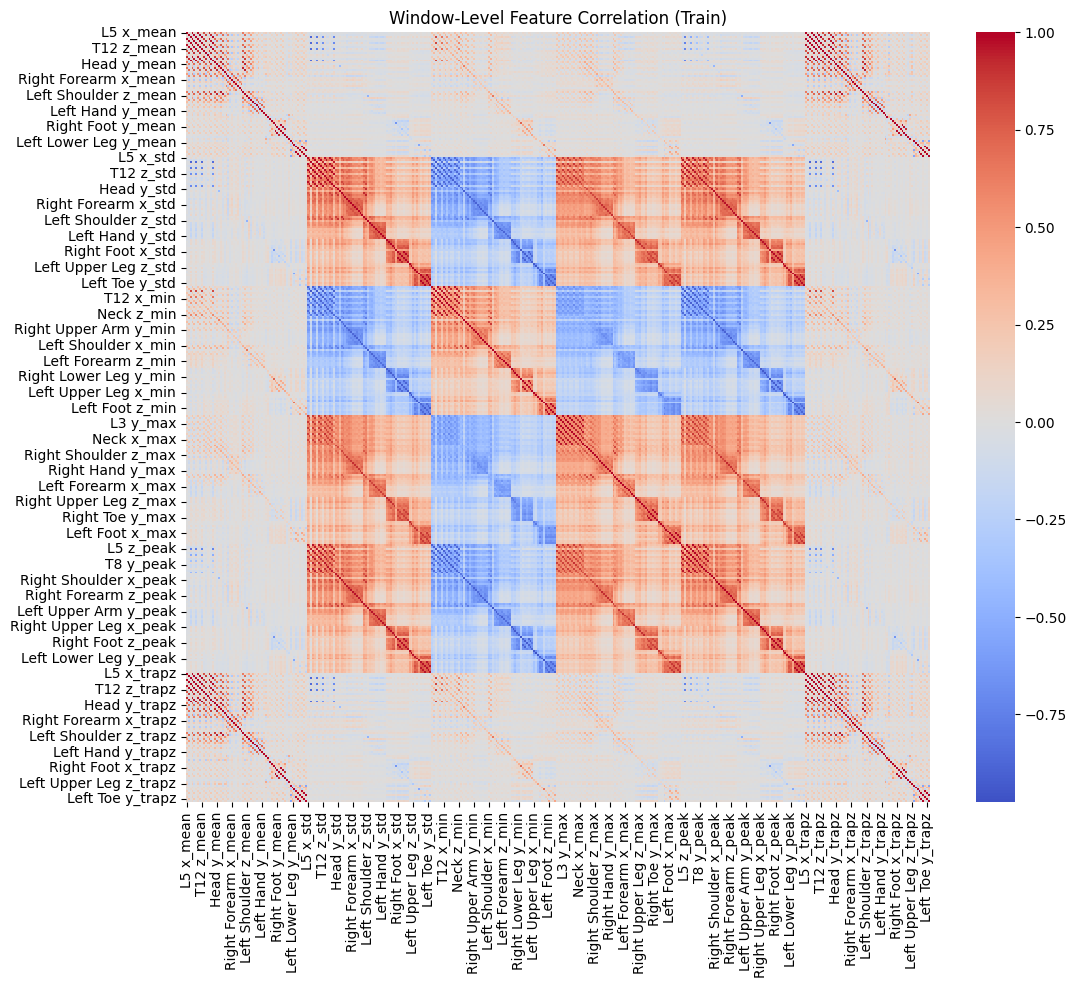

In [25]:
corr = X_train_win_v.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Window-Level Feature Correlation (Train)")
plt.show()


In [26]:
def drop_highly_correlated(df: pd.DataFrame, threshold: float = 0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train_corr, dropped_corr = drop_highly_correlated(X_train_win_v, threshold=0.9)
X_val_corr = X_val_win_v.drop(columns=dropped_corr)
X_test_corr = X_test_win_v.drop(columns=dropped_corr)

print(f"Dropped correlated columns: {len(dropped_corr)}")
print(f"Remaining columns: {X_train_corr.shape[1]}")


Dropped correlated columns: 230
Remaining columns: 164


In [27]:
label_encoder_win = LabelEncoder()
y_train_win_enc = label_encoder_win.fit_transform(y_train_win)
y_val_win_enc = label_encoder_win.transform(y_val_win)
y_test_win_enc = label_encoder_win.transform(y_test_win)

k = 5
selector = SelectKBest(score_func=f_classif, k=k)
X_train_k = selector.fit_transform(X_train_corr, y_train_win_enc)
X_val_k = selector.transform(X_val_corr)
X_test_k = selector.transform(X_test_corr)

selected_features = X_train_corr.columns[selector.get_support()].tolist()
print("Top features:", selected_features)

Top features: ['L5 z_mean', 'L5 z_std', 'Left Upper Leg z_std', 'Left Lower Leg y_std', 'Left Lower Leg y_max']


C:\Users\PCPV\AppData\Local\Temp\ipykernel_23016\2874976842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores.index, y=scores.values, palette=colors)


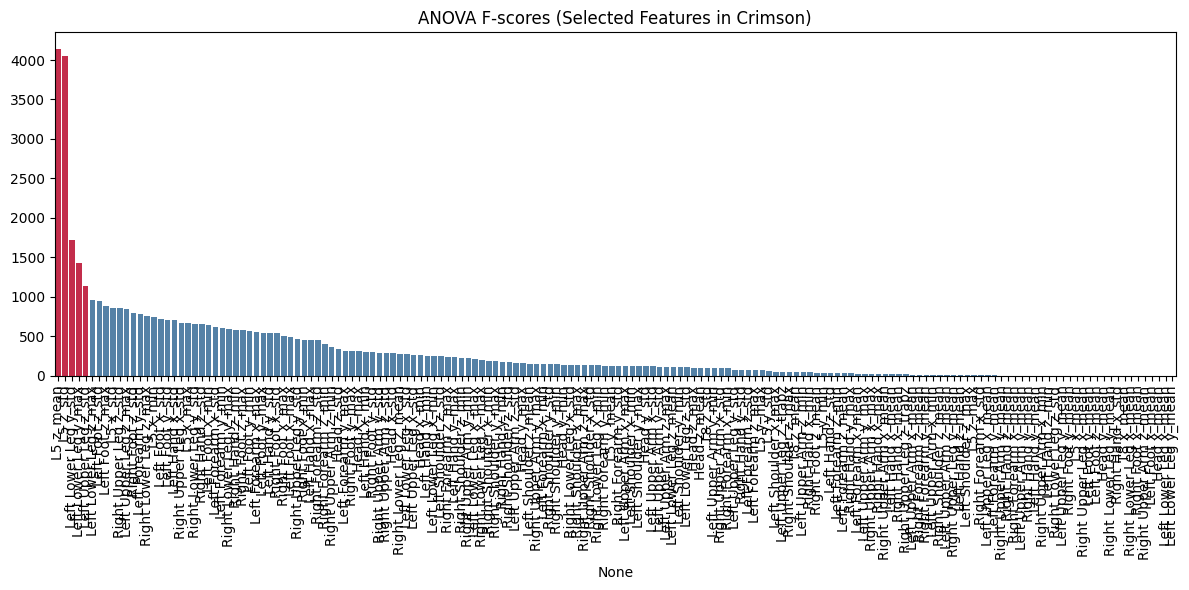

In [28]:
scores = pd.Series(selector.scores_, index=X_train_corr.columns).sort_values(ascending=False)
colors = ["crimson" if f in selected_features else "steelblue" for f in scores.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=scores.index, y=scores.values, palette=colors)
plt.xticks(rotation=90)
plt.title("ANOVA F-scores (Selected Features in Crimson)")
plt.tight_layout()
plt.show()

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_k)
X_val_scaled = scaler.transform(X_val_k)
X_test_scaled = scaler.transform(X_test_k)

In [30]:
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_win_enc)
    print(f"Trained {name}")

Trained DecisionTree
Trained RandomForest
Trained ExtraTrees


Validation - DecisionTree
Accuracy: 0.8333333333333334
Precision: 0.8862660944206009
Recall: 0.7410287081339713
F1: 0.8071661237785016
              precision    recall  f1-score   support

      boning       0.80      0.92      0.85      1880
     slicing       0.89      0.74      0.81      1672

    accuracy                           0.83      3552
   macro avg       0.84      0.83      0.83      3552
weighted avg       0.84      0.83      0.83      3552



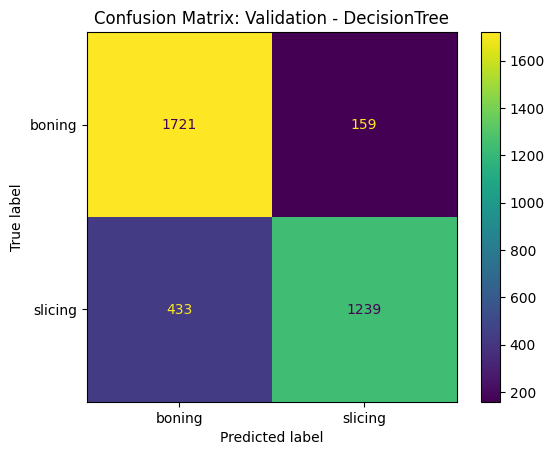

Validation - RandomForest
Accuracy: 0.8426238738738738
Precision: 0.8861901457321305
Recall: 0.763755980861244
F1: 0.8204304529392868
              precision    recall  f1-score   support

      boning       0.81      0.91      0.86      1880
     slicing       0.89      0.76      0.82      1672

    accuracy                           0.84      3552
   macro avg       0.85      0.84      0.84      3552
weighted avg       0.85      0.84      0.84      3552



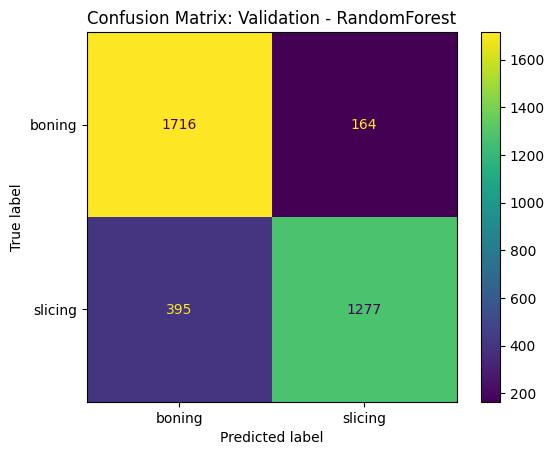

Validation - ExtraTrees
Accuracy: 0.8386824324324325
Precision: 0.9019751280175567
Recall: 0.7374401913875598
F1: 0.8114511352418559
              precision    recall  f1-score   support

      boning       0.80      0.93      0.86      1880
     slicing       0.90      0.74      0.81      1672

    accuracy                           0.84      3552
   macro avg       0.85      0.83      0.84      3552
weighted avg       0.85      0.84      0.84      3552



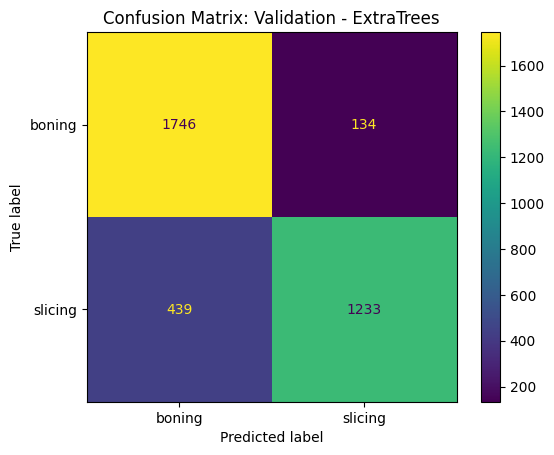

In [31]:
def evaluate(model, X, y_true, title: str):
    y_pred = model.predict(X)
    print(title)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="binary"))
    print("Recall:", recall_score(y_true, y_pred, average="binary"))
    print("F1:", f1_score(y_true, y_pred, average="binary"))
    print(classification_report(y_true, y_pred, target_names=label_encoder_win.classes_))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder_win.classes_)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

for name, model in models.items():
    evaluate(model, X_val_scaled, y_val_win_enc, f"Validation - {name}")

P2 Test - DecisionTree
Accuracy: 0.6243163172288059
Precision: 0.5836151822623074
Recall: 0.7418199187962742
F1: 0.6532758439373225
              precision    recall  f1-score   support

      boning       0.69      0.52      0.59      9178
     slicing       0.58      0.74      0.65      8374

    accuracy                           0.62     17552
   macro avg       0.64      0.63      0.62     17552
weighted avg       0.64      0.62      0.62     17552



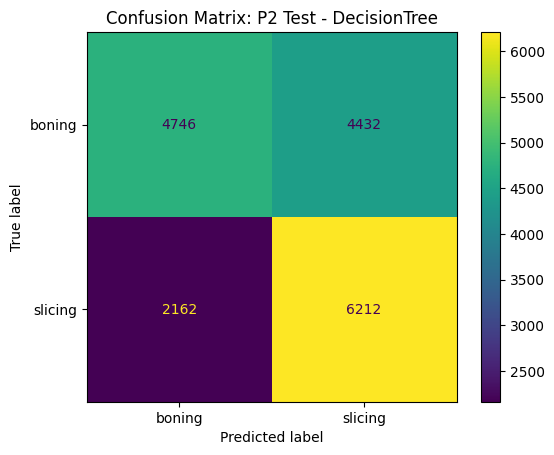

P2 Test - RandomForest
Accuracy: 0.6255697356426618
Precision: 0.5878852906749903
Recall: 0.719727728684022
F1: 0.647159884033072
              precision    recall  f1-score   support

      boning       0.68      0.54      0.60      9178
     slicing       0.59      0.72      0.65      8374

    accuracy                           0.63     17552
   macro avg       0.63      0.63      0.62     17552
weighted avg       0.64      0.63      0.62     17552



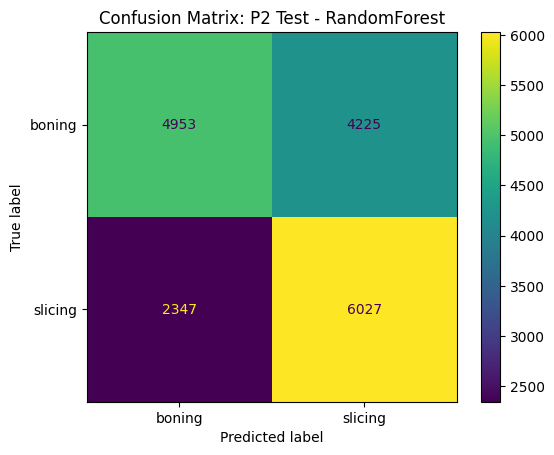

P2 Test - ExtraTrees
Accuracy: 0.6225501367365542
Precision: 0.5859628428192274
Recall: 0.7118461905899212
F1: 0.6427993745619237
              precision    recall  f1-score   support

      boning       0.67      0.54      0.60      9178
     slicing       0.59      0.71      0.64      8374

    accuracy                           0.62     17552
   macro avg       0.63      0.63      0.62     17552
weighted avg       0.63      0.62      0.62     17552



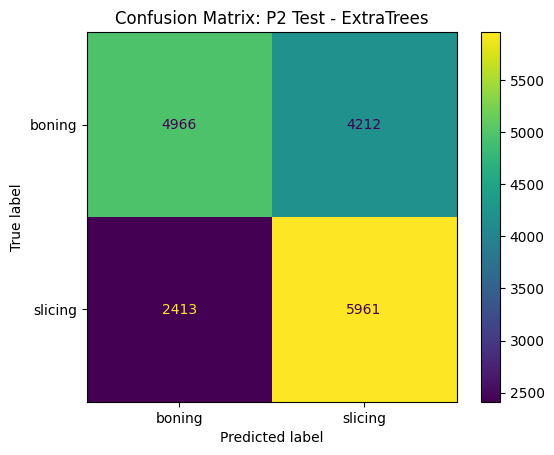

In [32]:
for name, model in models.items():
    evaluate(model, X_test_scaled, y_test_win_enc, f"P2 Test - {name}")

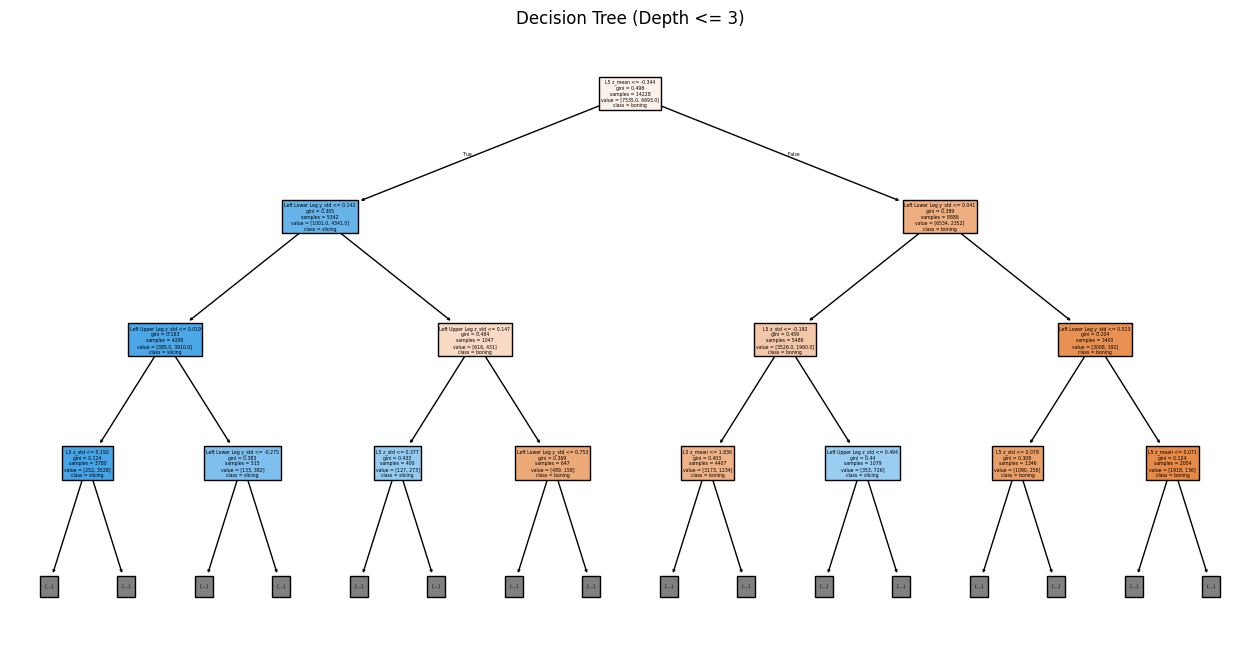

In [33]:
tree_model = models["DecisionTree"]
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=[f for f, keep in zip(X_train_corr.columns, selector.get_support()) if keep],
    class_names=label_encoder_win.classes_,
    filled=True,
    max_depth=3,
)
plt.title("Decision Tree (Depth <= 3)")
plt.show()

## Final Analysis

- Most informative features selected by ANOVA and tree-based models
- Effectiveness of window-based statistical features for boning vs slicing
- Limitations of classical ML for temporal motion data
- Motivation for temporal deep-learning models (e.g., TCN) as a next step